# AIM:
create evaluation workflow. Taking the manually extracted Ci impacts (validation set) and compare it with the CI impacts (llm_geolocations.ipynb) extrracted by the first LLM 1. 
As a first step the evaluation should be done only for the direct CI impacts - CI type, damage and geolocation

Issue:
* What is needed an approach that recognizes when an direct impact case is not detected by the model
Idea: 
* Split the original texts passed to the model on the exact chunks as again
* Then chunkwise check if the CI impacts from the validation set correspond in number and their textual similarity to the CI impacts infered by the LLM 1 and Entity Linking 

## Semantic Textual Similarity (STS)

Calculating the STS for both model configurations (chain of prompts, orchestration of models)
The outputs are cosine similarity scores for similar model outputs per chunk. They are ranked by score for each model, restricted to the top 20 results.  


In [18]:
import os
import sys
from pathlib import Path
import io
import gc
import time
import warnings
import subprocess
import importlib

import langdetect
from fuzzywuzzy import fuzz
import torch
from huggingface_hub import login
import numpy as np
import spacy
import pandas as pd
import torch
import pyarrow as pa
import pyarrow.parquet as pq
import pickle


# from utils.training import topic_search, topic_search_lm

sys.path.append('../')
from src.settings import settings as s
import src.document_cleaning as dc
import src.translation_model as tm


In [19]:
try: 
    login(token=os.getenv("HUGGINGFACE_TOKEN"))   # notebook_login
except:
    login(token=os.environ.get("HUGGINGFACE_TOKEN"))  # former HF_TOKEN



Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


### Direct CI impacts: LLM 1 vs domain-expertise 

In [20]:
#  Suppress future warnings from PyTorch
warnings.filterwarnings("ignore", category=FutureWarning)


#  Define data dir where tags.csv and domain-expertise derived tag lists are found 
VALID_DATA_FILENAME = "table_ci_impacts_sm.csv"
PATH_VALID_DATA = s.PATH_VALID_DATA
PATH_EVAL_RESULT = s.PATH_EVAL_RESULT
LLM_DATA_FILEPATH = Path(s.PATH_LLM_DATA / s.LLM_DATA_FILENAME) # "llm1_2026-02-11_7of9.csv" "llm_1_test_eval.csv"
SIMILARITY_LLM_FILENAME = s.SIMILARITY_LLM_FILENAME

df_valid = pd.read_csv(
    PATH_VALID_DATA / VALID_DATA_FILENAME,
    usecols=["publication_id", "ci1_type", "ci1_damage", "ci1_location", "sentence_reference"]
)
print(len(df_valid))
## pre-process: 
# remove undone entries
df_valid = df_valid[~df_valid.astype(str).apply(lambda x: x.str.contains("xx")).any(axis=1)]
#df_valid = df_valid[~df_valid[["publication_id", "ci1_type", "ci1_damage", "ci1_location", "sentence_reference"]].astype(str).apply(lambda x: x.str.contains("xx")).any(axis=1)]
df_valid = df_valid.dropna(subset=["publication_id"], how="all") # drop rows where all three columns are NaN
print(len(df_valid))



## prediction data
df_pred = pd.read_csv(
    LLM_DATA_FILEPATH,
    #usecols=["citation_id", "chunk_id", "infrastructure_type", "damage", "location", "chunk_text"]
)

df_pred 
## citation alignment
# print(df_pred["citation_id"])
# df_pred["citation_id"] = df_pred["citation_id"].map(dc.extract_citation_info) # FIXME as used with new funct returning author, year, title
# df_pred["citation_id"] = df_pred["citation_id"].apply(dc.extract_citation_info)
# print(df_pred["citation_id"])


141
136


,citation_id,chunk_id,infrastructure_type,damage,location,ci_entity,geo_entity,case_type,chunk_text
0,AEMET 2024,0,roads,severely damaged,Valencia,NaN,NaN,NaN,"STUDY ON THE SITUATION OF INTENSE, LOCALLY TOR..."
1,AEMET 2024,0,bridges,heavily destroyed,Alicante,NaN,NaN,NaN,"STUDY ON THE SITUATION OF INTENSE, LOCALLY TOR..."
2,AEMET 2024,0,railways,derailed,Castellon,NaN,NaN,NaN,"STUDY ON THE SITUATION OF INTENSE, LOCALLY TOR..."
3,AEMET 2024,0,ports,contaminated,Valencia,NaN,NaN,NaN,"STUDY ON THE SITUATION OF INTENSE, LOCALLY TOR..."
4,AEMET 2024,0,airports,outages,Alicante,NaN,NaN,NaN,"STUDY ON THE SITUATION OF INTENSE, LOCALLY TOR..."
...,...,...,...,...,...,...,...,...,...
1290,Containerlift 2024,4,Clydeside Containers Opening Plans,heavily destroyed,"Clydeside, Scotland",NaN,NaN,NaN,Shipping Container to Become Temporary Changin...
1291,Containerlift 2024,4,Shipping containers,heavily destroyed,"Newcastle, UK",NaN,NaN,NaN,Shipping Container to Become Temporary Changin...
1292,Containerlift 2024,4,Maritime power,disrupted,India,NaN,NaN,NaN,Shipping Container to Become Temporary Changin...
1293,Containerlift 2024,5,Port,severely damaged,"Valencia, Spain",NaN,NaN,NaN,Valencia Port Resumes Operations Following Dev...


#### Load spaCy language model

In [21]:
# !uv run python -m spacy download en_core_web_lg

# os.chdir("/home/a-buch/Documents/TUB_DWN/_PROJECTS/CI-impacts-information-retrieval")
# nlp = spacy.load("en_core_web_lg")

In [22]:
## load english model with word vectors included
s.SPACY_MODEL = "en_core_web_lg"

print(f"Try loading spaCy language model ({s.SPACY_MODEL}) for remote instance (e.g., cluster)")
try: 
    nlp = spacy.load(s.SPACY_MODEL)
except (OSError, ValueError):
    print(f"spaCy language model '{s.SPACY_MODEL}' not found. Downloading ...")
    subprocess.check_call(["uv", "pip", "install", "spacy-transformers"])
    subprocess.check_call(["uv", "run", "python", "-m", "spacy", "download", s.SPACY_MODEL])
    nlp = spacy.load(s.SPACY_MODEL)
        

# !uv run python -m spacy download en_core_web_lg
# nlp = spacy.load("en_core_web_lg")


Try loading spaCy language model (en_core_web_lg) for remote instance (e.g., cluster)


In [23]:
def cosine_similarity(vector_a, vector_b):
    dot_product = np.dot(vector_a, vector_b)
    magnitude_a = np.linalg.norm(vector_a)
    magnitude_b = np.linalg.norm(vector_b)
    return dot_product / (magnitude_a * magnitude_b)


In [24]:
# ## unify citation column

# # get corresponding document from df_vald
# citation_pattern = r"(.*?)(\d{4})(.*)" # split at first occurrence of year
# # df_pred["publication_id"] = df_pred["citation"].map(dc.extract_citation_info)
# df_pred["citation"].map(dc.extract_citation_info)
# # df_pred = df_pred.rename({"citation": "publiation_id"})
# # df_pred.drop("citation", inplace=True)
# df_pred
# # try:
# #     authors, year, _ = re.findall(citation_pattern, filename)[0]
# #     citation = f"{authors} {year}"



In [26]:
# df_pred_valid# .iloc[1].sentence_reference

In [27]:
# df_pred[df_pred["citation_id"] == "Koks 2022"]["infrastructure_type"].unique()
df_pred["citation_id"].unique()

array(['AEMET 2024', 'Karakatsani 2023', 'Khazai 2013',
       "Lloyd's List 2024", 'Containerlift 2024'], dtype=object)

#### Select  entries which have text references

In [ ]:

df_pred = df_pred[~df_pred["chunk_text"].isna()].reset_index(drop=True)
df_valid = df_valid[~df_valid["sentence_reference"].isna()].reset_index(drop=True)


#### Translation of validation sentences

In [ ]:

for entry in df_valid.itertuples():
    
    src_language = langdetect.detect(str(entry.sentence_reference))
    
    if src_language != "en":
        supported_languages = ["fr", "de", "es", "it", "itc", "nl"]
        if src_language not in supported_languages:
            print(f"Unsupported source language: {src_language}. Continue with original version of the sentence in validation set ")
            continue 

        print(f"\n ######## -------- Translating: {src_language} --> en -------- ######## \n")

        # clean up before applying translator
        gc.collect()
        torch.cuda.empty_cache()  # mainly after training needed, small effect when LLM applied only for inference
        torch.no_grad()
        
        # overwrite original sentence(s) with translated versions
        translated_sentence = tm.translate_2_english(src_language, str(entry.sentence_reference))
        df_valid.loc[df_valid.index[df_valid["sentence_reference"] == entry.sentence_reference], "sentence_reference"] = translated_sentence



 ######## -------- Translating: de --> en -------- ######## 

/home/a-buch/Documents/TUB_DWN/_PROJECTS/CI-impacts-information-retrieval/notebooks/huggingface_mirror/hub
Using device: cuda
Using locally saved model from /home/a-buch/Documents/TUB_DWN/_PROJECTS/CI-impacts-information-retrieval/notebooks/huggingface_mirror/hub


/home/a-buch/Documents/TUB_DWN/_PROJECTS/CI-impacts-information-retrieval/.venv/lib/python3.12/site-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Input document is a string (not DoclingObject). Wrapping it in a list for processing.
Continue with translation of text string
Source text:  Denn weil Brücken und Straßen in den braunen Wassermassen versanken, brachen die Logistikketten vieler Betriebe und setzten, weil Teile und Material fehlten, die Produktion matt. So stoppte Volkswagen Lastwagen stoppten vor zerstörten Brücken, Lastkähne konnten gar nicht erst
Translated text:  Because bridges and roads sank into the brown water masses, the logistics chains of many companies broke and, because parts and material were missing, set the production matt. Thus, Volkswagen trucks stopped from destroying bridges, load barges could not even stop at all.

 ######## -------- Translating: de --> en -------- ######## 

/home/a-buch/Documents/TUB_DWN/_PROJECTS/CI-impacts-information-retrieval/notebooks/huggingface_mirror/hub
Using device: cuda
Using locally saved model from /home/a-buch/Documents/TUB_DWN/_PROJECTS/CI-impacts-information-retriev

/home/a-buch/Documents/TUB_DWN/_PROJECTS/CI-impacts-information-retrieval/.venv/lib/python3.12/site-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Input document is a string (not DoclingObject). Wrapping it in a list for processing.
Continue with translation of text string
Source text:  In 46,1 % der erfassten Verkehrs- behinderungen handelt es sich um beidseitig gesperrte Straßen.
Translated text:  46,1 % of the traffic barriers detected are on both sides of the road.

 ######## -------- Translating: de --> en -------- ######## 

/home/a-buch/Documents/TUB_DWN/_PROJECTS/CI-impacts-information-retrieval/notebooks/huggingface_mirror/hub
Using device: cuda
Using locally saved model from /home/a-buch/Documents/TUB_DWN/_PROJECTS/CI-impacts-information-retrieval/notebooks/huggingface_mirror/hub


...

Input document is a string (not DoclingObject). Wrapping it in a list for processing.
Continue with translation of text string
Source text:  Il totale dei danni, ammonterebbe a più di 80 milioni di euro. L’incendio è avvenuto la scorsa domenica notte presso l’aeroporto Vincenzo Bellini di Catania e, dopo due giorni di incessante lavoro per lo spegnimento del fuoco, dal terminal C sono ripresi arrivi e partenze. 
Translated text:  The total of the damages, would amount to more than 80 million euros. The fire happened last Sunday night at the airport Vincenzo Bellini of Catania and, after two days of incessant work for the shutdown of the fire, from the terminal C are resumed arrivals and departures.

 ######## -------- Translating: it --> en -------- ######## 

/home/a-buch/Documents/TUB_DWN/_PROJECTS/CI-impacts-information-retrieval/notebooks/huggingface_mirror/hub
Using device: cuda
Using locally saved model from /home/a-buch/Documents/TUB_DWN/_PROJECTS/CI-impacts-information-retrieva

/home/a-buch/Documents/TUB_DWN/_PROJECTS/CI-impacts-information-retrieval/.venv/lib/python3.12/site-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Input document is a string (not DoclingObject). Wrapping it in a list for processing.
Continue with translation of text string
Source text:  Anche il territorio di Partinico non è stato risparmiato: l’incendio è divampato alcuni giorni fa sulla statale 113. 
Translated text:  Also the territory of Partinico was not spared: the fire blazed a few days ago on the highway 113.

 ######## -------- Translating: it --> en -------- ######## 

/home/a-buch/Documents/TUB_DWN/_PROJECTS/CI-impacts-information-retrieval/notebooks/huggingface_mirror/hub
Using device: cuda
Using locally saved model from /home/a-buch/Documents/TUB_DWN/_PROJECTS/CI-impacts-information-retrieval/notebooks/huggingface_mirror/hub


/home/a-buch/Documents/TUB_DWN/_PROJECTS/CI-impacts-information-retrieval/.venv/lib/python3.12/site-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Input document is a string (not DoclingObject). Wrapping it in a list for processing.
Continue with translation of text string
Source text:  Fiamme anche sulla strada provinciale 63 che collega la città al santuario della Madonna del Ponte
Translated text:  Flames also on the provincial road 63 that connects the city to the sanctuary of the Madonna del Ponte


#### Merge prediction entries with potential validation entries (nth:1 pairs)

In [ ]:
print("Match chunk text of each prediction entry with related validiation entries (nth:1 pairs)") # getting nth:1 pairs

df_pred_valid_all = pd.DataFrame()
threshold = 95 

# find for each prediction entry all validation entries for respective chunk 
# these validation entries are candidates from which the most similar one to the pred. entry is taken to calc. model recall 
for _, pred_entry in df_pred.iterrows():
    for _, valid_entry in df_valid.iterrows():  # all validation entries of all docs
        # Calculate match score by accounting for partial string matches. 
        # In detail, it calculates the similarity ratio using the shortest string (length n, here: "sentence_reference") against all n-length substrings of the larger string and returns the highest score 
        score = fuzz.partial_ratio(valid_entry['sentence_reference'], pred_entry['chunk_text'])
        # scores.append({'chunk_text': pred_entry['chunk_text'], 'sentence_reference': valid_entry['sentence_reference'], 'score': score})
        if score >= threshold:
            entry_pred_valid = {
                "citation_id": pred_entry["citation_id"],
                "ci_pred": pred_entry["infrastructure_type"],
                "damage_pred": pred_entry["damage"],
                "location_pred": pred_entry["location"],
                "chunk_id_pred": pred_entry["chunk_id"],
                "chunk_text_pred": pred_entry["chunk_text"],
                "ci_valid": valid_entry["ci1_type"],
                "damage_valid": valid_entry["ci1_damage"],
                "location_valid": valid_entry["ci1_location"],
                "sentence_text_valid": valid_entry["sentence_reference"],
                "text_similarity": score
            }
            df_pred_valid_all = pd.concat([df_pred_valid_all, pd.DataFrame([entry_pred_valid])], ignore_index=True)  # n:1 relationship DF
        
        # but keep also all False Negative cases (ie. where valid entry exists but no prediction)
        



Match chunk text of each prediction entry with related validiation entries (nth:1 pairs)


In [ ]:
df_pred_valid_all.info()

## --> FPs are more common compared to FNs, especially for predicting locations, 
# as it is easier to get a prep-valid match when pred.info is actually missing due to larger chunk-text (pred set) compared to sentence-text (valid set)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   citation_id              74 non-null     object
 1   ci_pred                  74 non-null     object
 2   damage_pred              74 non-null     object
 3   location_pred            74 non-null     object
 4   chunk_id_pred            74 non-null     int64 
 5   chunk_text_pred          74 non-null     object
 6   ci_valid                 59 non-null     object
 7   damage_valid             59 non-null     object
 8   location_valid           41 non-null     object
 9   sentence_text_valid      74 non-null     object
 10  sentence_text_valid_org  74 non-null     object
 11  text_similarity          74 non-null     int64 
dtypes: int64(2), object(10)
memory usage: 7.1+ KB


#### For each prediction entry, search for all validation cases of the same chunk 

In [63]:
# for i in df_pred_valid_all.groupby(["chunk_text_pred"])["sentence_text_valid"]:
#     print(i)
df_pred_valid_all

,citation_id,ci_pred,damage_pred,location_pred,chunk_text_pred,ci_valid,damage_valid,location_valid,sentence_text_valid,text_similarity_score
0,Karakatsani 2023,National Roads,severely damaged,Central Greece,The economic impact of the recent devastating ...,railway,Highly damaged,NaN,"National roads were closed, bridges colla...",99
1,Karakatsani 2023,National Roads,severely damaged,Central Greece,The economic impact of the recent devastating ...,bridges,destroyed,NaN,"National roads were closed, bridges colla...",99
2,Karakatsani 2023,National Roads,severely damaged,Central Greece,The economic impact of the recent devastating ...,roads,Directly affected,NaN,"National roads were closed, bridges colla...",99
3,Karakatsani 2023,Bridges,collapsed,Thessaly plain,The economic impact of the recent devastating ...,railway,Highly damaged,NaN,"National roads were closed, bridges colla...",99
4,Karakatsani 2023,Bridges,collapsed,Thessaly plain,The economic impact of the recent devastating ...,bridges,destroyed,NaN,"National roads were closed, bridges colla...",99
...,...,...,...,...,...,...,...,...,...,...
69,Containerlift 2024,Railways,disrupted,Valencia,Valencia Port Resumes Operations Following Dev...,Port infrastructure,affected,Port of Valencia,The Port of Valencia has reopened for operatio...,100
70,Containerlift 2024,Power,outages,Spain,Valencia Port Resumes Operations Following Dev...,Port infrastructure,affected,Port of Valencia,The Port of Valencia has reopened for operatio...,100
71,Containerlift 2024,road,severely damaged,eastern Spain,"In an advisory, shipping company Hapag-Lloyd n...",Port infrastructure,affected,Sagunto port,"Nevertheless, the reopening of Valencia and Sa...",99
72,Containerlift 2024,utility,disrupted,region,"In an advisory, shipping company Hapag-Lloyd n...",Port infrastructure,affected,Sagunto port,"Nevertheless, the reopening of Valencia and Sa...",99


In [84]:
columns_valid = ["ci_valid", "damage_valid", "location_valid"]
columns_pred = ["ci_pred", "damage_pred", "location_pred"]

df_pred_valid_smltry_all = pd.DataFrame()



for column_valid, column_pred in zip(columns_valid, columns_pred):

    print(f" --------- Calculate similarities for entries in column pair: {column_pred} - {column_valid} ------------")

    ## calc for each entry with the same chunk_text the similarity between valid_impact and pred_impact
    ## means we calc also the False Negatives (ie. where valid entry exists but no prediction)
    for chunk_grouped in df_pred_valid_all["chunk_text_pred"].unique():
        df_group = df_pred_valid_all[df_pred_valid_all["chunk_text_pred"] == chunk_grouped]


    for i, entry in df_group.iterrows():

        highest_similarity_score = 0 

        ## calculate embeddings

        ## TODO calc FN and FP based on Belgian approach with self-set threshold
        # which indicates when an entry pair is not similar
        ## TODO 2: calc also FP: i.e. when pred_info exists but not corresponding valid_info, and FNs (les FNs as wrong matches more likely due chunk-text is longer than sentence text)

        ## calc TPs and TNs when both pred_info and valid_info exist (ie. not NaN)
        if entry[column_pred] and entry[column_valid] is not np.nan:
            pred_impact = entry[column_pred]
            valid_impact = entry[column_valid]
            pred_vec = nlp(pred_impact).vector
            valid_vec = nlp(valid_impact).vector
   
            # calculate cosine similarity for each pred-valid pair
            similarity_score = cosine_similarity(pred_vec, valid_vec)  # 0-1 value, the higher the more similar
            # print(f"Similarity {i}-{j}: {similarity_score}")
            dict_pair = {
                "impact_valid": valid_impact, 
                "impact_pred": pred_impact, 
                "impact_similarity": similarity_score,
                "tp_tn_fp_fn": "tp_tn",
                "citation": entry.citation_id,
                #"chunk_id_pred": entry.chunk_id,
                "chunk_text_pred": entry.chunk_text_pred,
                "sentence_text_valid": entry.sentence_text_valid,
                }
            df_pred_valid_smltry_all = pd.concat([df_pred_valid_smltry_all, pd.DataFrame([dict_pair])], ignore_index=True)
    
        # ## FNs
        # # # calc FN when valid_info exists but not corresponding pred_info
        # ## number of FNs is small due that wrong matching with any chunk-text is more likely due to its text size comapred sentence-level (valid set) 
        # elif entry[column_pred] is np.nan:
        #     similarity_score = 0
        #     dict_pair = {
        #         "impact_valid": valid_impact, 
        #         "impact_pred": pred_impact, 
        #         "impact_similarity": similarity_score,
        #         "tp_tn_fp_fn": "fn",
        #         "citation": entry.citation_id,
        #         "chunk_text_pred": entry.chunk_text_pred,
        #         "sentence_text_valid": entry.sentence_text_valid,
        #         }
        #     df_pred_valid_smltry_all = pd.concat([df_pred_valid_smltry_all, pd.DataFrame([dict_pair])], ignore_index=True)
    
        # ## FPs
        # elif entry[column_valid] is np.nan:
        #     similarity_score = 0
        #     dict_pair = {
        #         "impact_valid": valid_impact, 
        #         "impact_pred": pred_impact, 
        #         "impact_similarity": similarity_score,
        #         "tp_tn_fp_fn": "fp",
        #         "citation": entry.citation_id,
        #         "chunk_text_pred": entry.chunk_text_pred,
        #         "sentence_text_valid": entry.sentence_text_valid,
        #         }
        #     df_pred_valid_smltry_all = pd.concat([df_pred_valid_smltry_all, pd.DataFrame([dict_pair])], ignore_index=True)
    

        #     pred_impact = entry[column_pred]
        #     pred_vec = nlp(pred_impact).vector

        # # calc FP (when chunk exists but not corresponding sentence_reference) when valid_info exists but not corresponding pred_info
        # if entry[column_valid] is np.nan:
        #     valid_impact = entry[column_valid]
        #     valid_vec = nlp(valid_impact).vector



    print(" ---------- Evaluation summary statistics: -----------")
    print(df_pred_valid_smltry_all.impact_similarity.describe())



## NOTE : decrease in result due that validation set contains only a subset of all Ci impacts mentioned in the doc --> thus we need to match on sentence-level (col. sentence_reference) 
# if chunk from prediction matches with sentence_reference of valid DS --> then calculate similarity, if not mathc: then continue with next entry

 --------- Calculate similarities for entries in column pair: ci_pred - ci_valid ------------
 ---------- Evaluation summary statistics: -----------
count    3.000000
mean     0.520148
std      0.269286
min      0.335520
25%      0.365652
50%      0.395785
75%      0.612463
max      0.829141
Name: impact_similarity, dtype: float64
 --------- Calculate similarities for entries in column pair: damage_pred - damage_valid ------------
 ---------- Evaluation summary statistics: -----------
count    6.000000
mean     0.552341
std      0.181185
min      0.335520
25%      0.431362
50%      0.538181
75%      0.642495
max      0.829141
Name: impact_similarity, dtype: float64
 --------- Calculate similarities for entries in column pair: location_pred - location_valid ------------
 ---------- Evaluation summary statistics: -----------
count    9.000000
mean     0.451806
std      0.212252
min      0.157112
25%      0.321916
50%      0.395785
75%      0.538269
max      0.829141
Name: impact_similari

In [49]:
df_pred_valid_smltry_all

""


In [ ]:
df_pred_valid_smltry_all

In [ ]:
# ## match based on (cosine) similarity 
# # see also: Levenshtein distance which measures the number of edits (ie. the effort) to change a string into the other)
# # https://medium.com/@caskcadellc/string-matching-in-pandas-techniques-and-examples-4041db161be9

# df_pred_valid = pd.DataFrame()


# df_pred_e = df_pred[~df_pred["chunk_text"].isna()].reset_index(drop=True)
# df_valid_e = df_valid[~df_valid["sentence_reference"].isna()].reset_index(drop=True)


# # find for each prediction entry all validation entries for respective chunk 
# # these validation entries are all candidates from which the most similar one to the pred. enry is taken to calc. model recall 
# threshold = 95 
# for _, pred_entry in df_pred_e.iterrows():
#     for _, valid_entry in df_valid_e.iterrows():  # all validation entries of all docs
#         # Calculate match score by accounting for partial string matches. 
#         # In detail, it calculates the similarity ratio using the shortest string (length n, here: "sentence_reference") against all n-length substrings of the larger string and returns the highest score 
#         score = fuzz.partial_ratio(valid_entry['sentence_reference'], pred_entry['chunk_text'])
#         # scores.append({'chunk_text': pred_entry['chunk_text'], 'sentence_reference': valid_entry['sentence_reference'], 'score': score})
#         if score >= threshold:
#             entry_pred_valid = {
#                 "citation_id": pred_entry["citation_id"],
#                 "ci_pred": pred_entry["infrastructure_type"],
#                 "damage_pred": pred_entry["damage"],
#                 "location_pred": pred_entry["location"],
#                 "chunk_text_pred": pred_entry["chunk_text"],
#                 "ci_valid": valid_entry["ci1_type"],
#                 "damage_valid": valid_entry["ci1_damage"],
#                 "location_valid": valid_entry["ci1_location"],
#                 "sentence_text_valid": valid_entry["sentence_reference"],
#                 "text_similarity_score": score
#             }
#             df_pred_valid = pd.concat([df_pred_valid, pd.DataFrame([entry_pred_valid])], ignore_index=True)

# # Same approach as above but just using cartesian product of pred and valid entrries and then filter out low similarity scores.
# # df_pred_valid = df_valid_e.merge(df_pred_e, how="cross")  
# # # calculate score for each pair
# # # df_pred_valid["score"] = df_pred_valid.apply(lambda row: fuzz.partial_ratio(row["sentence_reference"], row["chunk_text"]), axis=1) 
# # df_pred_valid["score"] = df_pred_valid.apply(lambda row: fuzz.partial_ratio(row['chunk_text'], row['sentence_reference']), axis=1) 
# # ### -_> filter pairs based on very high threshold to ensure 1:1 and 1:nth pairs to avoid dublicated prediction entires in merged df
# # df_pred_valid = df_pred_valid[df_pred_valid["score"] >= threshold]
# # print(len(df_pred_valid))
# # df_pred_valid

#### For each validation entry, search for all prediction cases of the same chunk 

In [ ]:
## get same impact entries
columns_valid = ["ci1_type", "ci1_damage", "ci1_location"]
columns_pred = ["infrastructure_type", "damage", "location"]


for column_valid, column_pred in zip(columns_valid, columns_pred):

    print(f" --------- Processing column pair: {column_valid} - {column_pred} ------------")
    
    df_valid_pred_all = pd.DataFrame()
    citations_list = []

    ## for each validation record
    for i in range(len(df_valid)):
        
        highest_similarity_score = 0.00
        
        ## needed to traceback info when entry is missing in pred. DS
        # chunk_id_value_valid = df_valid.chunk_id[i]

        # select nth validation record and check that it has value
        df_valid_entry = df_valid.iloc[i]
        if df_valid_entry[column_valid] is np.nan:
            continue
        
        citation_str = df_valid_entry.publication_id
        citations_list.append(citation_str)


        # get all corresponding prediction records
        df_pred_entries = df_pred[df_pred["citation_id"].isin([citation_str])]

        #  handle on NANs
        df_pred_entries[column_pred] = np.where(df_pred_entries[column_pred].isna(), "nan", df_pred_entries[column_pred])
        # df_pred_entries[column_pred] = df_pred_entries[column_pred].astype(str)
        # remove double whitespaces
        # df_pred_doc[column_pred] = df_pred_doc[column_pred].replace("  ", " ")
        # df_valid_entries[column_valid] = df_valid_entries[column_valid].replace("  ", " ")


        # vector of validiation entry 
        valid_impact = df_valid_entry[column_valid]
        valid_vec = nlp(valid_impact).vector

        # print(" ------- Searching for citation:", citation_str, " in predictions ------- ")

        # Compute similarity between each validation CI impact case and all potential predicted CI impact cases (cross-product)
        for j in range(len(df_pred_entries[column_pred])):

            if df_pred_entries[column_pred].iloc[j] == "nan":
                continue

            pred_impact = df_pred_entries[column_pred].iloc[j]

            pred_vec = nlp(pred_impact).vector
            similarity_score = cosine_similarity(valid_vec, pred_vec)  # 0-1 value, the higher the more similar
            # print(f"Similarity {i}-{j}: {similarity_score}")

            # print(f"Searching for highest similarity ... ")
            ## get only pair with highest similarity
            if similarity_score > highest_similarity_score:
                
                highest_similarity_score = similarity_score
                
                dict_pair = {
                    "impact_valid": valid_impact, 
                    "impact_pred": pred_impact, 
                    "similarity": highest_similarity_score,
                    "citation": citation_str,
                    "chunk_id_pred": (df_pred.chunk_id[i],  df_pred.chunk_id[j])
                }
            else:
                continue

        df_valid_pred_all = pd.concat([df_valid_pred_all, pd.DataFrame([dict_pair])], ignore_index=True)


    print(f" ---------- Evaluation summary statistics - {column_pred}: -----------")
    print(df_valid_pred_all.similarity.describe())

    

    SIMILARITY_FILENAME = f'{column_pred}_{SIMILARITY_LLM_FILENAME}'
    SIMILARITY_FILEPATH = Path(PATH_EVAL_RESULT / SIMILARITY_FILENAME)

    print("Saving evaluation statistics, distribution plots, and scores to ", SIMILARITY_FILEPATH.stem, "[.parquet, _stats.json]")
    with open(SIMILARITY_FILEPATH, 'w') as f:
        # results
        df_valid_pred_all.to_csv(SIMILARITY_FILEPATH.with_suffix('.csv'), index=False)
        df_valid_pred_all_pyarrow = pa.Table.from_pandas(df_valid_pred_all)
        pq.write_table(df_valid_pred_all_pyarrow, SIMILARITY_FILEPATH)   
        #   summary statistics
        df_valid_pred_all_stats = df_valid_pred_all.describe()
        f = SIMILARITY_FILEPATH.parent / f"{SIMILARITY_FILEPATH.stem}_stats.json"  
        df_valid_pred_all_stats.to_json(f, indent=4)
        # distribution plots
        df_valid_pred_all.similarity.hist(bins=100).to_file(SIMILARITY_FILEPATH.parent / f"{SIMILARITY_FILEPATH.stem}_hist.png")



    # similarity_threshold = 0.75
    # df_valid_pred_all['is_similar'] = df_valid_pred_all['similarity'] <= similarity_threshold
    # print(f"Number of similar impact cases (similarity >= {similarity_threshold}): {df_valid_pred_all['is_similar'].sum()} out of {len(df_valid_pred_all)}\n")

    # df_valid_pred_all =  df_valid_pred_all[df_valid_pred_all['similarity'] <= similarity_threshold]

    # SIMILARITY_FILENAME = f'{column_pred}_lower75_{SIMILARITY_LLM_FILENAME}'
    # SIMILARITY_FILEPATH = Path(PATH_EVAL_RESULT / SIMILARITY_FILENAME)

    # with open(SIMILARITY_FILEPATH, 'w') as f:
    #     # results
    #     df_valid_pred_all.to_csv(SIMILARITY_FILEPATH.with_suffix('.csv'), index=False)
    #     df_valid_pred_all_pyarrow = pa.Table.from_pandas(df_valid_pred_all)
    #     pq.write_table(df_valid_pred_all_pyarrow, SIMILARITY_FILEPATH)  
    #     #   summary statistics
    #     df_valid_pred_all_stats = df_valid_pred_all.describe()
    #     f = SIMILARITY_FILEPATH.parent / f"{SIMILARITY_FILEPATH.stem}_stats.json"  
    #     df_valid_pred_all_stats.to_json(f, indent=4)


 --------- Processing column pair: ci1_type - infrastructure_type ------------


/tmp/ipykernel_32745/2878094738.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pred_entries[column_pred] = np.where(df_pred_entries[column_pred].isna(), "nan", df_pred_entries[column_pred])
/tmp/ipykernel_32745/2640203756.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return dot_product / (magnitude_a * magnitude_b)


 ---------- Evaluation summary statistics - infrastructure_type: -----------
count    106.000000
mean       0.800988
std        0.165914
min        0.544855
25%        0.600174
50%        0.791639
75%        1.000000
max        1.000000
Name: similarity, dtype: float64


<Axes: >

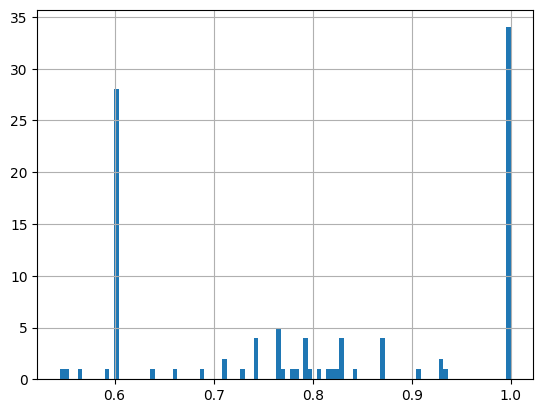

In [ ]:
# df_valid_pred_all[df_valid_pred_all['similarity'] <= 0.75]

# df_valid_pred_all.similarity.hist(bins=100)

In [81]:
columns_pred

['infrastructure_type', 'damage', 'location']

In [35]:
LLM_DATA_FILEPATH

PosixPath('../data/llm_outputs/llm1_2026-02-11_7of9_old.csv')

### Load parquet file

In [22]:

columns_pred = ["infrastructure_type", "damage", "location"]

In [ ]:
column_pred = "infrastructure_type"
SIMILARITY_FILENAME = f'llm1_similarity_{column_pred}_75.parquet'
SIMILARITY_FILEPATH = Path(PATH_EVAL_RESULT / SIMILARITY_FILENAME)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    df = pd.read_parquet(SIMILARITY_FILEPATH, engine='pyarrow')
    display(df)

## Archive

In [ ]:
# ## get same impact entries
# columns_valid = ["ci1_type", "ci1_damage", "ci1_location"]
# columns_pred = ["infrastructure_type", "damage", "location"]



## iterate over predictions and search for each prediction reocrds for corresponding valid cases 

# for column_valid, column_pred in zip(columns_valid, columns_pred):

#     print(f" --------- Processing column pair: {column_valid} - {column_pred} ------------")
    
#     df_valid_pred_all = pd.DataFrame()
#     citations_list = []

#     ## for each validation record
#     for i in range(len(df_valid)):
        
#         highest_similarity_score = 0.00
        
#         ## needed to traceback info when entry is missing in pred. DS
#         # chunk_id_value_valid = df_valid.chunk_id[i]

#         # select nth validation record
#         df_valid_entry = df_valid.iloc[i]
#         citation_str = df_valid_entry.publication_id
#         citations_list.append(citation_str)
#         print(" ------- Searching for citation:", citation_str, " in predictions ------- ")


#         # get all corresponding prediction records
#         df_pred_entries = df_pred[df_pred["citation_id"].isin([citation_str])]
#         #  handle on NANs
#         df_pred_entries[column_pred] = np.where(df_pred_entries[column_pred].isna(), "nan", df_pred_entries[column_pred])
#         # df_pred_entries[column_pred] = df_pred_entries[column_pred].astype(str)
#         # remove double whitespaces
#         # df_pred_doc[column_pred] = df_pred_doc[column_pred].replace("  ", " ")
#         # df_valid_entries[column_valid] = df_valid_entries[column_valid].replace("  ", " ")

#         # skip when validation entry ha no value
#         if df_valid_entry[column_valid] is np.nan:
#             continue

#         # vector of validiation entry 
#         valid_impact = df_valid_entry[column_valid]
#         valid_vec = nlp(valid_impact).vector


#         # Compute similarity between each predicted impact case and all potential validation impact cases (cross-product)
#         # print(f"Searching for highest similarity of`{pred_impact}` in validation set ... ")
#         for j in range(len(df_pred_entries[column_pred])):

#             if df_pred_entries[column_pred].iloc[j] == "nan":
#                 continue

#             pred_impact = df_pred_entries[column_pred].iloc[j]

#             pred_vec = nlp(pred_impact).vector
#             similarity_score = cosine_similarity(valid_vec, pred_vec)  # 0-1 value, the higher the more similar
#             # print(f"Similarity {i}-{j}: {similarity_score}")

#             ## get only pair with highest similarity
#             if similarity_score > highest_similarity_score:
                
#                 highest_similarity_score = similarity_score
                
#                 dict_pair = {
#                     "impact_valid": valid_impact, 
#                     "impact_pred": pred_impact, 
#                     "similarity": highest_similarity_score,
#                     "citation": citation_str,
#                     "chunk_id_pred": df_pred.chunk_id[i]
#                 }
#             else:
#                 continue

#         df_valid_pred_all = pd.concat([df_valid_pred_all, pd.DataFrame([dict_pair])], ignore_index=True)


#     print(" ---------- Evaluation summary statistics: -----------")
#     print(df_valid_pred_all.similarity.describe())



#     SIMILARITY_FILENAME = f'{SIMILARITY_LLM_FILENAME}_{column_pred}.parquet'
#     SIMILARITY_FILEPATH = Path(PATH_EVAL_RESULT / SIMILARITY_FILENAME)

#     print("Saving evaluation statistics and scores to ", SIMILARITY_FILEPATH.stem, "[.parquet, _stats.json]")
#     with open(SIMILARITY_FILEPATH, 'w') as f:
#         # results
#         df_valid_pred_all_pyarrow = pa.Table.from_pandas(df_valid_pred_all)
#         pq.write_table(df_valid_pred_all_pyarrow, SIMILARITY_FILEPATH)   
#         #   summary statistics
#         df_valid_pred_all_stats = df_valid_pred_all.describe()
#         f = SIMILARITY_FILEPATH.parent / f"{SIMILARITY_FILEPATH.stem}_stats.json"  
#         df_valid_pred_all_stats.to_json(f, indent=4)



#     similarity_threshold = 0.75
#     df_valid_pred_all['is_similar'] = df_valid_pred_all['similarity'] >= similarity_threshold
#     print(f"Number of similar impact cases (similarity >= {similarity_threshold}): {df_valid_pred_all['is_similar'].sum()} out of {len(df_valid_pred_all)}")

#     SIMILARITY_FILENAME = f'{SIMILARITY_LLM_FILENAME}_{column_pred}_75.parquet'
#     SIMILARITY_FILEPATH = Path(PATH_EVAL_RESULT / SIMILARITY_FILENAME)

#     with open(SIMILARITY_FILEPATH, 'w') as f:
#         # results
#         df_valid_pred_all_pyarrow = pa.Table.from_pandas(df_valid_pred_all)
#         pq.write_table(df_valid_pred_all_pyarrow, SIMILARITY_FILEPATH)  
#         #   summary statistics
#         df_valid_pred_all_stats = df_valid_pred_all.describe()
#         f = SIMILARITY_FILEPATH.parent / f"{SIMILARITY_FILEPATH.stem}_stats.json"  
#         df_valid_pred_all_stats.to_json(f, indent=4)


In [ ]:

# #  Define folder for handling and writing outputs
# def write_to_file(data, out_folder, filename):
#     """Convert output to DataFrame and write to file"""
#     df = pd.DataFrame(list(data), columns=['tag', 'sts_score'])
#     #  Sort the DataFrame by similarity (explicitly)
#     df = df.sort_values(by='sts_score', ascending=False)
#     #  Assign integers to ranking
#     df['rank'] = df['sts_score'].rank(method='first', ascending=False).astype(int)
#     #  Only keep the first 20 resulting tags
#     df = df.head(50)
#     #  Save to file
#     df.to_csv(out_folder / f'{filename}_output.csv', index=False)

# #  Fill run metrics to dictionary
# def handle_metrics(metrics, model_name, length, end_time, start_time):
#     print(f'-> Took {end_time - start_time:.2f} seconds. Number of tags: {length}.')
#     metrics.append({
#         'modelname': model_name,
#         'runtime': round(end_time - start_time, 2),
#         'tagcount': length
#     })
#     return metrics

# class CPU_Unpickler(pickle.Unpickler):
#     """Fix for having issues with loading models on CPU"""
#     def find_class(self, module, name):
#         if module == 'torch.storage' and name == '_load_from_bytes':
#             return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
#         else: return super().find_class(module, name)
